# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)
| Nama              | NRP        |
|-------------------|------------|
|     Intifada Afkar Lazain Muhammad         |   5054251029|

**Sumber data:** SteamSpy API (`https://steamspy.com/api.php`)

## 1. Scraping Dataset
Data diambil dari SteamSpy API menggunakan `requests`. Karena endpoint `all` hanya mengembalikan 1.000 baris per halaman dan dibatasi 1 request per menit, proses scraping dilakukan dengan loop `page` disertai `time.sleep(60)`. Hasil scraping mentah disimpan ke `steamspy_data.json` agar proses scraping tidak perlu diulang setiap kali notebook dijalankan.

In [2]:
import requests
import json
import time
import pandas as pd

In [2]:
all_data = {}

for page in range(3):
    response = requests.get("https://steamspy.com/api.php", params={"request": "all", "page": page})
    data = response.json()
    all_data.update(data)
    time.sleep(60)

with open("steamspy_data.json", "w", encoding="utf-8") as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

## 2. Import dan Pemahaman Dataset

### 2.1 Import Dataset
Dataset dalam steamspy_data.json yang sudah tersimpan dibaca 

In [3]:
df = pd.read_json("steamspy_data.json")
df = df.T  
df = df.reset_index(drop=True) 

### 2.2 Ukuran dan Struktur Dataset

In [4]:
len(df)

3000

In [5]:
df.shape

(3000, 17)

In [6]:
df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,,7642084,1173003,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,,668053,326926,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",,1520457,1037487,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,,358266,22443,0,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,,1044264,117208,0,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819


In [7]:
df

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,,7642084,1173003,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,,668053,326926,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",,1520457,1037487,0,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,,358266,22443,0,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,,1044264,117208,0,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,307960,IL-2 Sturmovik: Battle of Stalingrad,FOR-GAMES CR LTD,FOR-GAMES CR LTD,,7142,1888,0,"200,000 .. 500,000",0,0,0,0,1249,4999,75,179
2996,32390,STAR WARS Jedi Knight - Mysteries of the Sith,LucasArts,"LucasArts, Lucasfilm, Disney",,650,329,0,"200,000 .. 500,000",0,0,0,0,119,299,60,2
2997,1216320,Shieldwall,Nezon Production,Nezon Production,,5662,836,0,"200,000 .. 500,000",0,0,0,0,1799,1799,0,41
2998,214870,Painkiller Hell & Damnation,The Farm 51,Prime Matter,,3258,919,0,"200,000 .. 500,000",0,0,0,0,1999,1999,0,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   appid            3000 non-null   object
 1   name             3000 non-null   object
 2   developer        3000 non-null   object
 3   publisher        3000 non-null   object
 4   score_rank       3000 non-null   object
 5   positive         3000 non-null   object
 6   negative         3000 non-null   object
 7   userscore        3000 non-null   object
 8   owners           3000 non-null   object
 9   average_forever  3000 non-null   object
 10  average_2weeks   3000 non-null   object
 11  median_forever   3000 non-null   object
 12  median_2weeks    3000 non-null   object
 13  price            3000 non-null   object
 14  initialprice     3000 non-null   object
 15  discount         3000 non-null   object
 16  ccu              3000 non-null   object
dtypes: object(17)
memory usage: 398.6

In [9]:
df.dtypes

appid              object
name               object
developer          object
publisher          object
score_rank         object
positive           object
negative           object
userscore          object
owners             object
average_forever    object
average_2weeks     object
median_forever     object
median_2weeks      object
price              object
initialprice       object
discount           object
ccu                object
dtype: object

In [10]:
df.columns

Index(['appid', 'name', 'developer', 'publisher', 'score_rank', 'positive',
       'negative', 'userscore', 'owners', 'average_forever', 'average_2weeks',
       'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount',
       'ccu'],
      dtype='object')

### 2.3 Identifikasi Tipe Atribut
`nunique()` digunakan untuk melihat jumlah nilai unik tiap kolom, membantu menentukan apakah suatu atribut bersifat kategorikal (nominal/ordinal) atau numerik.

In [11]:
df.nunique()

appid              3000
name               2978
developer          2006
publisher          1462
score_rank            2
positive           2843
negative           2306
userscore             2
owners                9
average_forever       1
average_2weeks        1
median_forever        1
median_2weeks         1
price               125
initialprice         67
discount             32
ccu                 996
dtype: int64

Berdasarkan struktur data di atas, atribut dapat diklasifikasikan sebagai berikut:

| Atribut | Tipe | Keterangan |
|---|---|---|
| `appid` | Identifier | ID unik, bukan atribut analitik (bukan numerik bermakna) |
| `name`, `developer`, `publisher` | Nominal | Kategori teks tanpa urutan |
| `score_rank` | Ordinal | Peringkat skor (mayoritas kosong) |
| `owners` | Nominal/rentang teks | Dikonversi menjadi `owners_numeric` (numerik kontinu) |
| `positive`, `negative`, `ccu` | Numerik diskrit | Hasil hitung (count) |
| `userscore` | Numerik diskrit | Skor pengguna |
| `average_forever`, `average_2weeks`, `median_forever`, `median_2weeks` | Numerik kontinu | Durasi bermain (menit) |
| `price`, `initialprice` | Numerik kontinu | Harga (setelah dikonversi dari sen) |
| `discount` | Numerik diskrit | Persentase diskon |

In [12]:
print(df['score_rank'].unique())
print(df['userscore'].unique())
print(df['average_forever'].unique())
print(df['average_2weeks'].unique())
print(df['median_forever'].unique())
print(df['median_2weeks'].unique())

['' 100]
[0 95]
[0]
[0]
[0]
[0]


In [13]:
df.drop(columns=['appid','userscore','score_rank','average_forever','average_2weeks', 'median_forever', 'median_2weeks'],inplace=True)
df

,name,developer,publisher,positive,negative,owners,price,initialprice,discount,ccu
0,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,1013936
1,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,124262
2,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,314682
3,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",2999,2999,0,18028
4,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,43819
...,...,...,...,...,...,...,...,...,...,...
2995,IL-2 Sturmovik: Battle of Stalingrad,FOR-GAMES CR LTD,FOR-GAMES CR LTD,7142,1888,"200,000 .. 500,000",1249,4999,75,179
2996,STAR WARS Jedi Knight - Mysteries of the Sith,LucasArts,"LucasArts, Lucasfilm, Disney",650,329,"200,000 .. 500,000",119,299,60,2
2997,Shieldwall,Nezon Production,Nezon Production,5662,836,"200,000 .. 500,000",1799,1799,0,41
2998,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",1999,1999,0,4


## 3. Analisis Statistik dan Kualitas Data

### 3.1 Penanganan Tipe Data (Data Cleaning)
Beberapa kolom numerik masih tersimpan sebagai string/object, misalnya `price` dalam satuan sen dan `owners` dalam bentuk rentang teks (misal `"1,000,000 .. 2,000,000"`). Kolom-kolom ini dikonversi terlebih dahulu agar dapat dianalisis secara statistik.

In [65]:
df['price'] = pd.to_numeric(df['price'], errors='coerce') / 100
df['initialprice'] = pd.to_numeric(df['initialprice'], errors='coerce') / 100
df['name'] = df['name'].astype('string')
df['developer'] = df['developer'].astype('string')
df['publisher'] = df['publisher'].astype('string')
def parse_owners(x):
    low, high = x.replace(",", "").split(" .. ")
    return (int(low) + int(high)) / 2

df['owners_numeric'] = df['owners'].apply(parse_owners)
df['discount']= pd.to_numeric(df['discount'])
df['ccu']= pd.to_numeric(df['ccu'])
df['owners_numeric']= pd.to_numeric(df['owners_numeric'])
df['positive']= pd.to_numeric(df['positive'])
df['negative']= pd.to_numeric(df['negative'])

In [66]:
df

,name,developer,publisher,positive,negative,owners,price,initialprice,discount,ccu,owners_numeric
0,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0.000000,0.000000,0,1013936,150000000.0
1,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0.000000,0.000000,0,124262,150000000.0
2,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0.000000,0.000000,0,314682,150000000.0
3,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0.000030,0.000030,0,18028,75000000.0
4,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0.000000,0.000000,0,43819,75000000.0
...,...,...,...,...,...,...,...,...,...,...,...
2995,IL-2 Sturmovik: Battle of Stalingrad,FOR-GAMES CR LTD,FOR-GAMES CR LTD,7142,1888,"200,000 .. 500,000",0.000012,0.000050,75,179,350000.0
2996,STAR WARS Jedi Knight - Mysteries of the Sith,LucasArts,"LucasArts, Lucasfilm, Disney",650,329,"200,000 .. 500,000",0.000001,0.000003,60,2,350000.0
2997,Shieldwall,Nezon Production,Nezon Production,5662,836,"200,000 .. 500,000",0.000018,0.000018,0,41,350000.0
2998,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0.000020,0.000020,0,4,350000.0


In [67]:
df.dtypes

name              string[python]
developer         string[python]
publisher         string[python]
positive                   int64
negative                   int64
owners                    object
price                    float64
initialprice             float64
discount                   int64
ccu                        int64
owners_numeric           float64
dtype: object

### 3.2 Statistik Deskriptif Atribut Numerik
`describe()` menampilkan mean, standar deviasi, min, maks, dan kuartil (termasuk median pada persentil 50%). Modus dihitung terpisah karena tidak disertakan oleh `describe()`.

In [68]:
print(df.describe())

           positive      negative         price  initialprice     discount  \
count  3.000000e+03  3.000000e+03  3.000000e+03   3000.000000  3000.000000   
mean   3.691281e+04  5.750147e+03  1.467891e-05      0.000017     9.072333   
std    1.715763e+05  3.278232e+04  1.508212e-05      0.000016    24.049433   
min    0.000000e+00  0.000000e+00  0.000000e+00      0.000000     0.000000   
25%    3.990250e+03  6.390000e+02  9.900000e-07      0.000002     0.000000   
50%    9.972500e+03  1.535500e+03  9.990000e-06      0.000015     0.000000   
75%    2.489700e+04  3.773750e+03  1.999000e-05      0.000025     0.000000   
max    7.642084e+06  1.173003e+06  7.999000e-05      0.000100    95.000000   

                ccu  owners_numeric  
count  3.000000e+03    3.000000e+03  
mean   1.789265e+03    2.593067e+06  
std    2.055495e+04    7.404325e+06  
min    0.000000e+00    3.500000e+05  
25%    1.100000e+01    7.500000e+05  
50%    7.150000e+01    7.500000e+05  
75%    3.872500e+02    1.500000

In [69]:
kolom_numerik = df.select_dtypes(include='number')
kolom_numerik = kolom_numerik.columns
modus = df[kolom_numerik].mode().iloc[0]
print(modus)

positive               0.0
negative               2.0
price                  0.0
initialprice           0.0
discount               0.0
ccu                    0.0
owners_numeric    750000.0
Name: 0, dtype: float64


In [70]:
kolom_numerik

Index(['positive', 'negative', 'price', 'initialprice', 'discount', 'ccu',
       'owners_numeric'],
      dtype='object')

### 3.3 Distribusi/Frekuensi Atribut Kategorikal

In [71]:
df['developer'].value_counts().head(10)

developer
Valve                     31
CAPCOM Co., Ltd.          24
Square Enix               19
Ubisoft Montreal          16
id Software               14
Visual Concepts           13
Firaxis Games             13
Obsidian Entertainment    12
Bethesda Game Studios     12
Codemasters               11
Name: count, dtype: Int64

In [72]:
df['publisher'].value_counts().head(10)

publisher
Electronic Arts       80
Ubisoft               64
SEGA                  63
Bethesda Softworks    50
2K                    50
Square Enix           46
Xbox Game Studios     38
Devolver Digital      35
Valve                 32
THQ Nordic            32
Name: count, dtype: Int64

### 3.4 Nilai yang Hilang (Missing Values)

In [73]:
df.isnull().sum()

name              0
developer         0
publisher         0
positive          0
negative          0
owners            0
price             0
initialprice      0
discount          0
ccu               0
owners_numeric    0
dtype: int64

### 3.5 Deteksi Outlier
Deteksi outlier dilakukan menggunakan metode IQR (Interquartile Range): nilai dianggap outlier jika berada di luar rentang `Q1 - 1.5*IQR` sampai `Q3 + 1.5*IQR`.

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
def detect_outliers_iqr(kolom):
    data_kolom = pd.to_numeric(df[kolom], errors='coerce')
    Q1 = data_kolom.quantile(0.25)
    Q3 = data_kolom.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    outliers = data_kolom[(data_kolom < batas_bawah) | (data_kolom > batas_atas)]
    return len(outliers)

kolom_numerik = df.select_dtypes(include='number').columns

for kolom in kolom_numerik:
    jumlah_outlier = detect_outliers_iqr(kolom)
    print(f"{kolom}: {jumlah_outlier} outlier")

positive: 369 outlier
negative: 341 outlier
price: 153 outlier
initialprice: 119 outlier
discount: 400 outlier
ccu: 452 outlier
owners_numeric: 663 outlier


**Visualisasi outlier per atribut numerik (boxplot)**

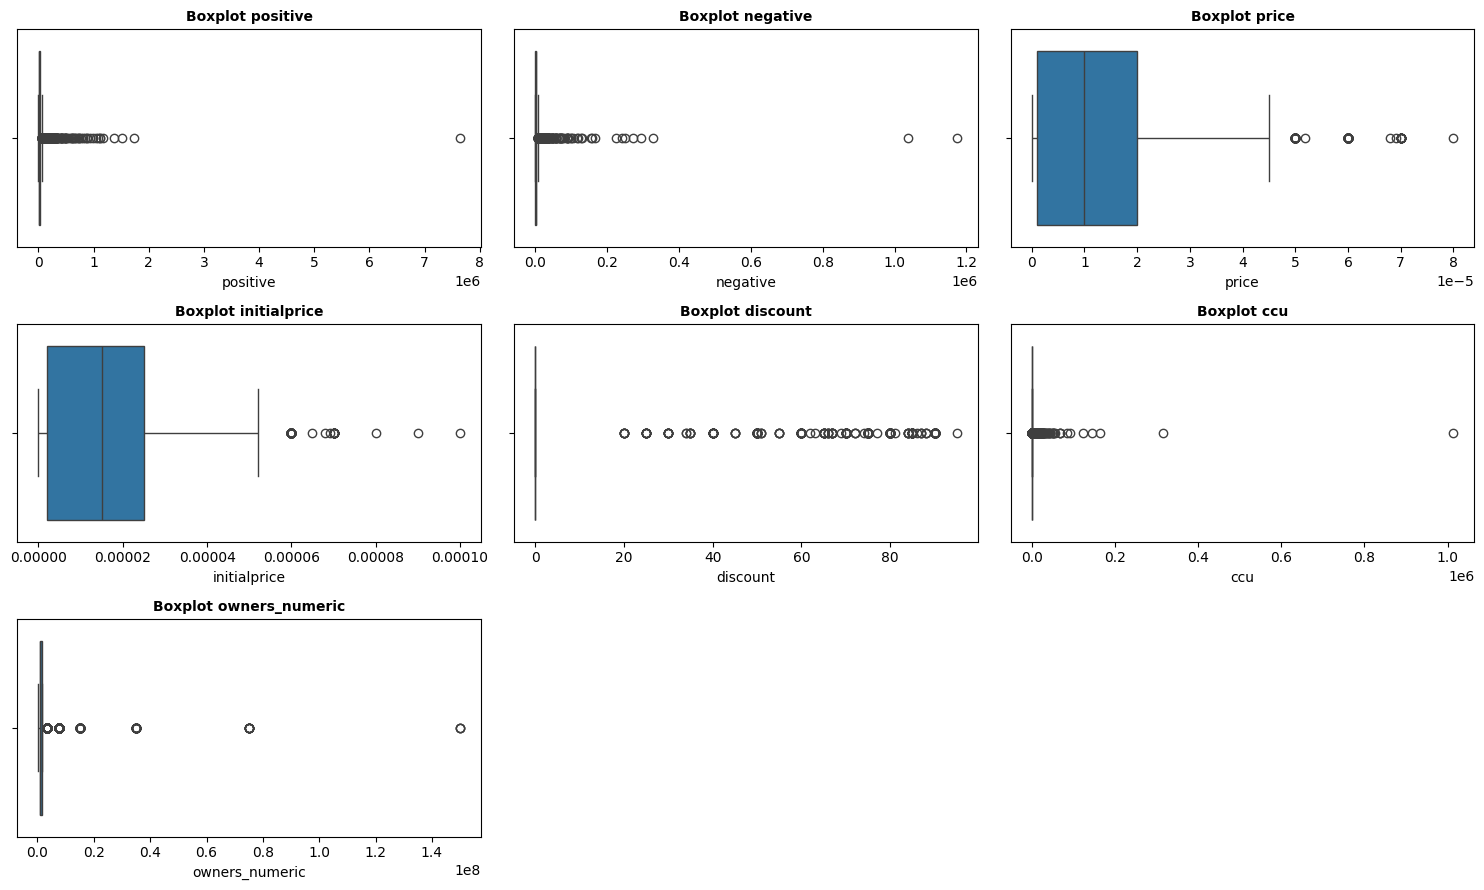

In [76]:
n_kolom = len(kolom_numerik)
n_cols = 3
n_rows = -(-n_kolom // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.boxplot(x=df[kolom], ax=axes[i])
    axes[i].set_title(f'Boxplot {kolom}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(kolom)

for j in range(n_kolom, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:** Outlier banyak terjadi di positive, negative, discount, ccu karena rata rata game berada pada angka 0 yang berarti banyak game steam yang tidak memiliki atribut tersebut

## 4. Visualisasi Data

### 4.1 Visualisasi Univariat

**Histogram atribut numerik**

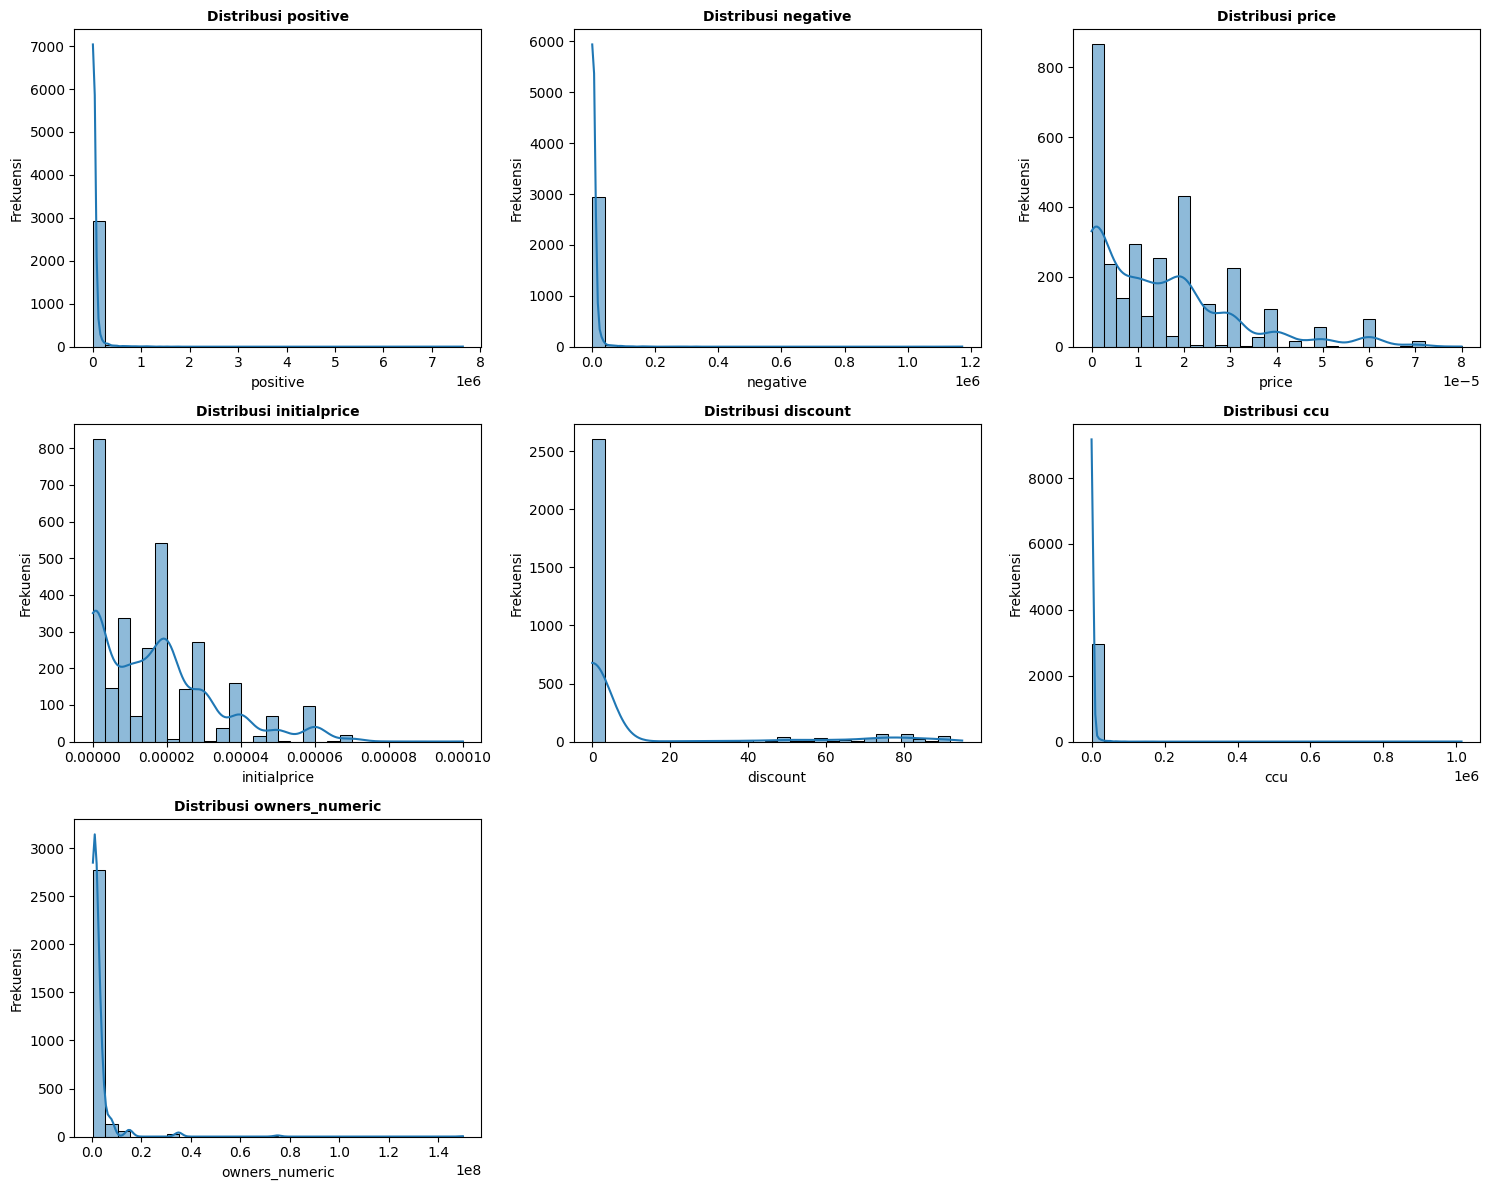

In [77]:
n_kolom = len(kolom_numerik)
n_cols = 3
n_rows = -(-n_kolom // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.histplot(df[kolom], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {kolom}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('Frekuensi')

for j in range(n_kolom, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight:** Data terlihat dominan skewed ke kanan karena banyak kategori dengan nilai 0 di banyak baris data yang berarti kebanyakan game di steam gagal mendapat nilai yang mencukupi pada kategori kategori tersebut


**Bar chart atribut kategorikal**

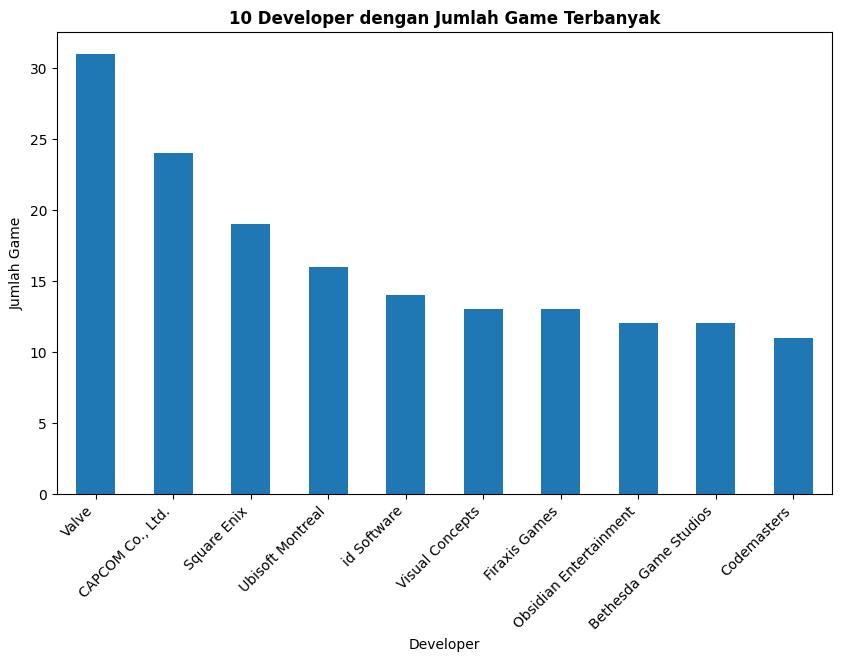

In [78]:
plt.figure(figsize=(10, 6))
df['developer'].value_counts().head(10).plot(kind='bar')
plt.title('10 Developer dengan Jumlah Game Terbanyak', fontsize=12, fontweight='bold')
plt.xlabel('Developer')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45, ha='right')
plt.show()

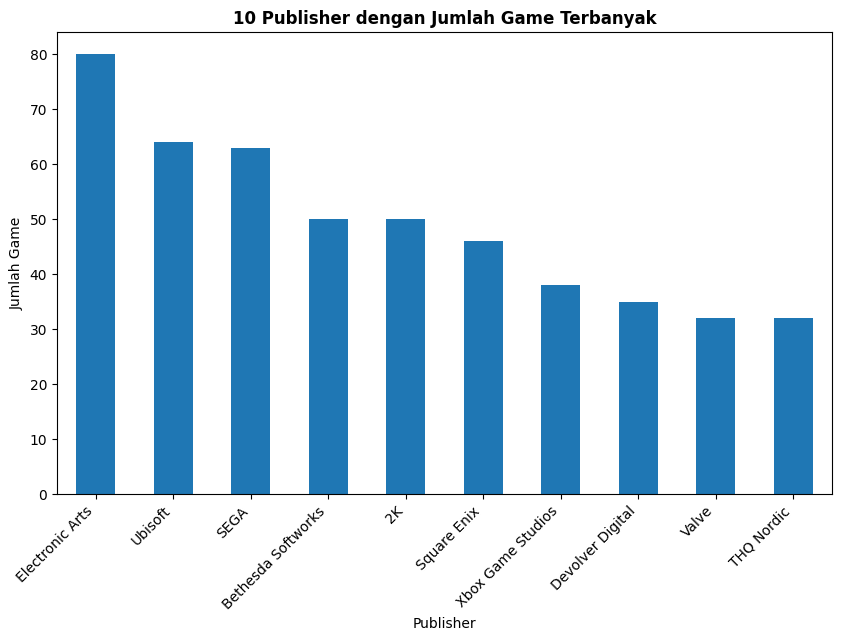

In [79]:
plt.figure(figsize=(10, 6))
df['publisher'].value_counts().head(10).plot(kind='bar')
plt.title('10 Publisher dengan Jumlah Game Terbanyak', fontsize=12, fontweight='bold')
plt.xlabel('Publisher')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45, ha='right')
plt.show()

### 4.2 Visualisasi Bivariat

**Correlation heatmap (sebelum data cleaning kolom)**

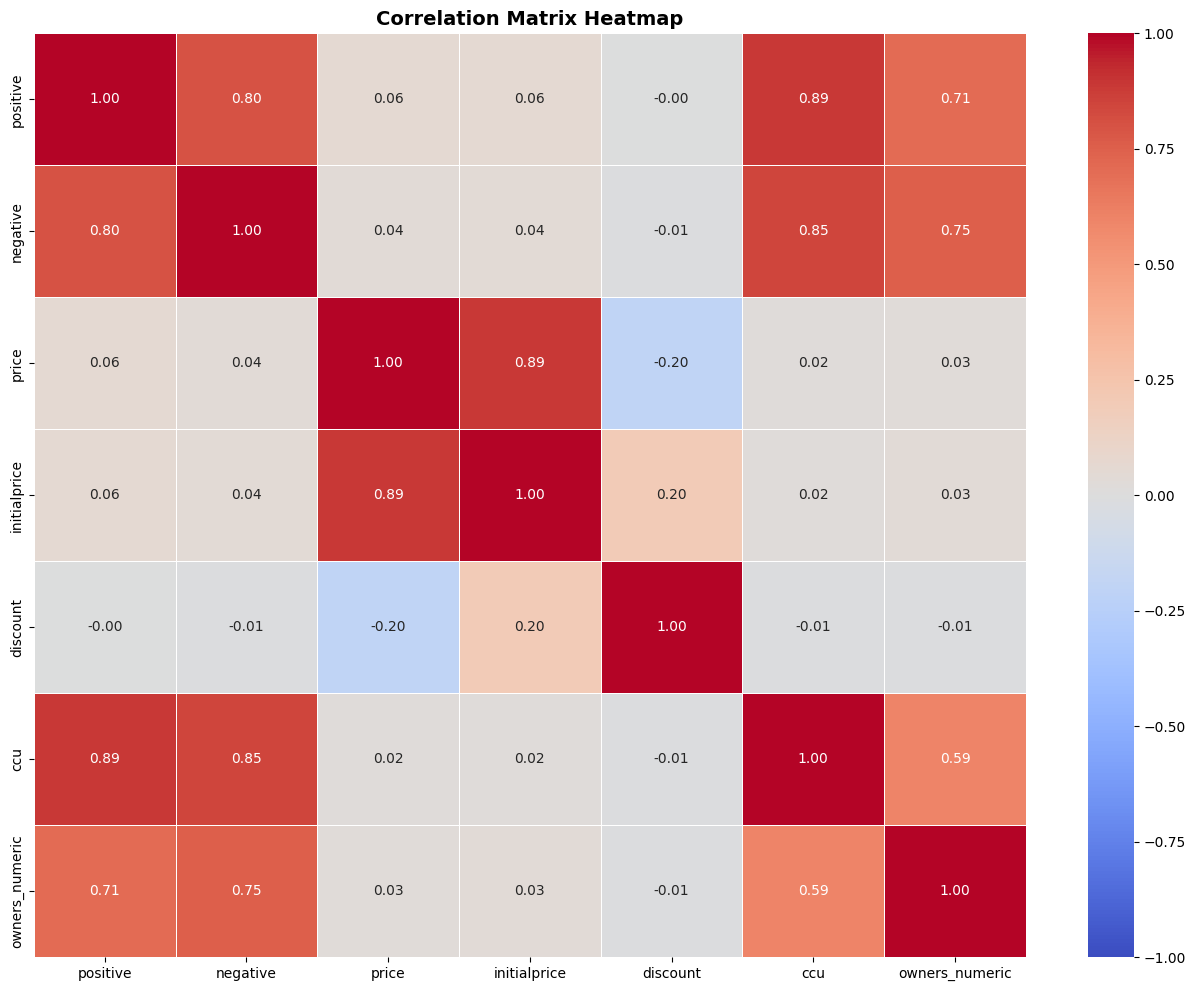

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.corr(method="pearson", numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    vmin=-1, vmax=1,    
    fmt='.2f',           
    linewidths=0.5       
)

plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [81]:
df

,name,developer,publisher,positive,negative,owners,price,initialprice,discount,ccu,owners_numeric
0,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0.000000,0.000000,0,1013936,150000000.0
1,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0.000000,0.000000,0,124262,150000000.0
2,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0.000000,0.000000,0,314682,150000000.0
3,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0.000030,0.000030,0,18028,75000000.0
4,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0.000000,0.000000,0,43819,75000000.0
...,...,...,...,...,...,...,...,...,...,...,...
2995,IL-2 Sturmovik: Battle of Stalingrad,FOR-GAMES CR LTD,FOR-GAMES CR LTD,7142,1888,"200,000 .. 500,000",0.000012,0.000050,75,179,350000.0
2996,STAR WARS Jedi Knight - Mysteries of the Sith,LucasArts,"LucasArts, Lucasfilm, Disney",650,329,"200,000 .. 500,000",0.000001,0.000003,60,2,350000.0
2997,Shieldwall,Nezon Production,Nezon Production,5662,836,"200,000 .. 500,000",0.000018,0.000018,0,41,350000.0
2998,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0.000020,0.000020,0,4,350000.0


**Insight:** Terlihat pada heatmap positive dan negative memiliki keterhubungan yang sangat dekat hal ini dikarenakan positive dan negatif sangat dipengaruhi oleh popularitas game yang digambarkan dengan hubungan dengan ccu dan owners_numeric yang juga sangat besar

**Scatter plot: hubungan dua atribut numerik**

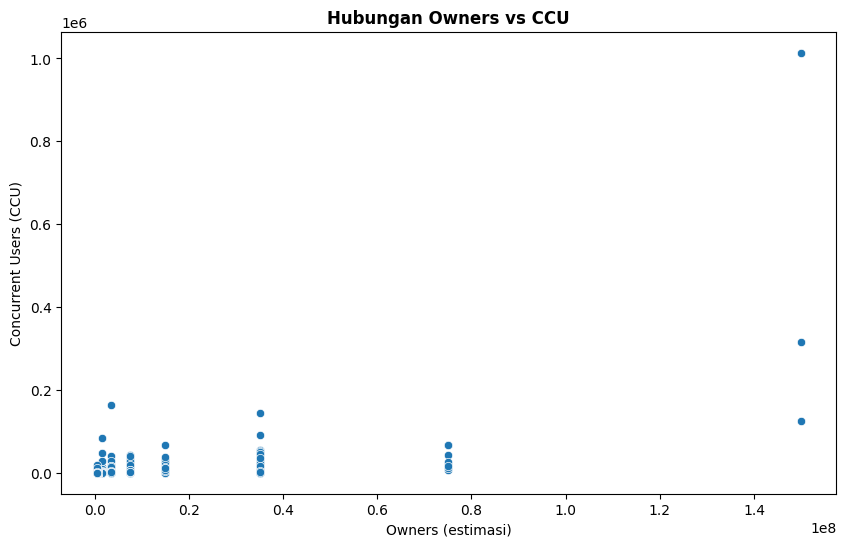

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='owners_numeric', y='ccu')
plt.title('Hubungan Owners vs CCU', fontsize=12, fontweight='bold')
plt.xlabel('Owners (estimasi)')
plt.ylabel('Concurrent Users (CCU)')
plt.show()

**Insight:** Hubungan antara owners dan ccu tidak selalu naik/positif, hal ini berarti jumlah player yang rutin memainkan game tidak selalu berdasarkan banyak orang memiliki game tersebut, ini bisa disebabkan karena banyak owner hanya memiliki game di library mereka tapi tidak pernah dimainkan atau mungkin dulu dimainkan tapi sudah bosan sehingga tidak dimainkan lagi

**Boxplot per kategori**

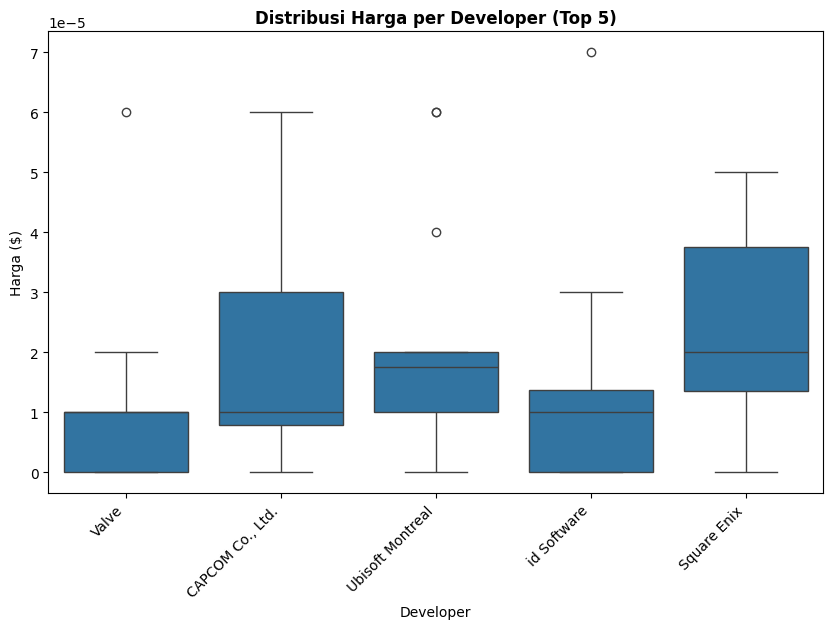

In [83]:
top_developer = df['developer'].value_counts().head(5).index
df_top_dev = df[df['developer'].isin(top_developer)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_dev, x='developer', y='price')
plt.title('Distribusi Harga per Developer (Top 5)', fontsize=12, fontweight='bold')
plt.xlabel('Developer')
plt.ylabel('Harga ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** Tidak banyak outlier pada distribusi harga top developer artinya developer memang sudah menentukan rentan harga game mereka sejak awal jadi harga gamenya tidak jauh jauh. Harga game juga ditentukan dari genre dan fokus game seperti valve yang terkenal akan game kompetitifnya sehingga mengandalkan jumlah player yang bermain sehingga merendahkan harganya sehingga banyak player yang bisa memainkan game nya beda dengan capcom,ubisoft,square enix yang fokus pada game console dan story yang pengembangannya sangat lama dan keseruannya tidak bergantung pada jumlah player yang bermain sehingga lebih mahal

## 5. Analisis Tambahan (Opsional)
Eksplorasi lanjutan: game dan developer dengan nilai tertinggi pada tiap atribut numerik.

In [84]:
colomns = [x for x in df.columns if x not in["name","developer","publisher","score_rank"]]
colomns

['positive',
 'negative',
 'owners',
 'price',
 'initialprice',
 'discount',
 'ccu',
 'owners_numeric']

In [85]:
from IPython.display import display

for x in colomns:
    most = df.sort_values(x, ascending=False).head(10).reset_index()
    most_name = most[['name','developer','publisher',x]]
    print(f"most in {x} category")
    display(most_name)

most in positive category


,name,developer,publisher,positive
0,Counter-Strike: Global Offensive,Valve,Valve,7642084
1,Grand Theft Auto V Legacy,Rockstar North,Rockstar Games,1739980
2,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457
3,Terraria,Re-Logic,Re-Logic,1373979
4,Tom Clancy's Rainbow Six Siege,Ubisoft Montreal,Ubisoft,1172854
5,Garry's Mod,Facepunch Studios,Valve,1122546
6,Black Myth: Wukong,Game Science,Game Science,1111720
7,Rust,Facepunch Studios,Facepunch Studios,1071135
8,Team Fortress 2,Valve,Valve,1044264
9,ELDEN RING,"FromSoftware, Inc.","FromSoftware, Inc., Bandai Namco Entertainment",981540


most in negative category


,name,developer,publisher,negative
0,Counter-Strike: Global Offensive,Valve,Valve,1173003
1,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1037487
2,Apex Legends,Respawn,Electronic Arts,326926
3,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,294520
4,War Thunder,Gaijin Entertainment,Gaijin Network Ltd,272617
5,Grand Theft Auto V Legacy,Rockstar North,Rockstar Games,250576
6,HELLDIVERS 2,Arrowhead Game Studios,PlayStation Publishing LLC,241752
7,Tom Clancy's Rainbow Six Siege,Ubisoft Montreal,Ubisoft,225730
8,Dead by Daylight,Behaviour Interactive Inc.,Behaviour Interactive Inc.,166993
9,Battlefield 2042,DICE,Electronic Arts,158588


most in owners category


...

,name,developer,publisher,discount
0,SAMOLIOTIK,"Volens Nolens Games, Nikita P. Chiril G.",Volens Nolens Games,95
1,Castle Crashers,The Behemoth,The Behemoth,90
2,CryoFall,AtomicTorch Studio,Daedalic Entertainment,90
3,Serious Sam 3: BFE,Croteam,Devolver Digital,90
4,Injustice 2,"NetherRealm Studios, QLOC",WB Games,90
5,Hitman: Contracts,Io-Interactive A/S,Io-Interactive A/S,90
6,Sniper Elite 4,Rebellion,Rebellion,90
7,Sid Meier’s Civilization VI,"Firaxis Games, Aspyr (Mac), Aspyr (Linux)","2K, Aspyr (Mac), Aspyr (Linux)",90
8,shapez,Tobias Springer,"tobspr Games, Doyoyo Games",90
9,INDUSTRIA,Bleakmill,"Headup, Beep Japan",90


most in ccu category


,name,developer,publisher,ccu
0,Counter-Strike: Global Offensive,Valve,Valve,1013936
1,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",314682
2,ELDEN RING NIGHTREIGN,"FromSoftware, Inc.","FromSoftware, Inc., Bandai Namco Entertainment",163599
3,Rust,Facepunch Studios,Facepunch Studios,143870
4,Apex Legends,Respawn,Electronic Arts,124262
5,Wallpaper Engine,Wallpaper Engine Team,Wallpaper Engine Team,91184
6,DELTARUNE,tobyfox,tobyfox,83936
7,Grand Theft Auto V Legacy,Rockstar North,Rockstar Games,67851
8,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,67419
9,NARAKA: BLADEPOINT,24 Entertainment,NetEase Games Global,66954


most in owners_numeric category


,name,developer,publisher,owners_numeric
0,Counter-Strike: Global Offensive,Valve,Valve,150000000.0
1,Apex Legends,Respawn,Electronic Arts,150000000.0
2,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",150000000.0
3,Palworld,Pocketpair,Pocketpair,75000000.0
4,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,75000000.0
5,Black Myth: Wukong,Game Science,Game Science,75000000.0
6,Team Fortress 2,Valve,Valve,75000000.0
7,Grand Theft Auto V Legacy,Rockstar North,Rockstar Games,75000000.0
8,Lost Ark,Smilegate RPG,Amazon Games,75000000.0
9,Unturned,Smartly Dressed Games,Smartly Dressed Games,75000000.0


**Rasio like/dislike per developer** (difilter minimal 1.000 total review agar tidak bias oleh developer dengan review sangat sedikit)

In [86]:
dev_stats = df.groupby('developer')[['positive', 'negative']].sum().reset_index()

dev_stats['total_reviews'] = dev_stats['positive'] + dev_stats['negative']

dev_stats_filtered = dev_stats[dev_stats['total_reviews'] >= 1000]

dev_stats_filtered['like_dislike_ratio'] = dev_stats_filtered['positive'] / dev_stats_filtered['negative']

dev_stats_filtered = dev_stats_filtered.sort_values('like_dislike_ratio', ascending=False)

dev_stats_filtered.head(10)

C:\Users\Lazzain\AppData\Local\Temp\ipykernel_25392\3670572135.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_stats_filtered['like_dislike_ratio'] = dev_stats_filtered['positive'] / dev_stats_filtered['negative']


,developer,positive,negative,total_reviews,like_dislike_ratio
835,Igara Studio,21620,198,21818,109.191919
929,KayAnimate,37623,363,37986,103.644628
1911,YUZUSOFT,30868,358,31226,86.223464
695,GB Patch Games,12306,146,12452,84.287671
1327,PuffballsUnited,50017,681,50698,73.446402
1943,ghosthunter,13689,194,13883,70.561856
1956,mestiez,277746,4017,281763,69.142644
1963,poncle,246479,3855,250334,63.937484
352,ConcernedApe,872384,13811,886195,63.165882
1643,TVGS,200803,3238,204041,62.014515


**Developer dengan total tertinggi pada tiap atribut numerik**

In [87]:

for x in colomns:
    dev_owners = df.groupby('developer')[x].sum().reset_index().sort_values(x, ascending=False).head(10)
    print(f"most developer in {x} category")
    display(dev_owners)

most developer in positive category


,developer,positive
1822,Valve,11594191
618,Facepunch Studios,2193681
678,"FromSoftware, Inc.",2006961
1414,Rockstar North,1783559
268,"CAPCOM Co., Ltd.",1729263
271,CD PROJEKT RED,1706409
1238,PUBG Corporation,1520457
1779,Ubisoft Montreal,1513561
1363,Re-Logic,1373979
170,Bethesda Game Studios,1331431


most developer in negative category


,developer,negative
1822,Valve,1414856
1238,PUBG Corporation,1037487
1400,Respawn,347849
268,"CAPCOM Co., Ltd.",299251
411,DICE,295745
1744,"Treyarch, Raven Software, Beenox, High Moon St...",294520
1779,Ubisoft Montreal,288438
701,Gaijin Entertainment,273842
1414,Rockstar North,269966
100,Arrowhead Game Studios,251003


most developer in owners category


...

,developer,discount
268,"CAPCOM Co., Ltd.",904
637,Firaxis Games,580
685,Frozenbyte,400
848,Infinity Ward,395
285,Capcom,384
422,Daedalic Entertainment,360
381,Croteam,350
1510,"Sledgehammer Games, Raven Software",270
1365,Reality Pump Studios,265
839,Image & Form Games,255


most developer in ccu category


,developer,ccu
1822,Valve,1105324
1238,PUBG Corporation,314682
678,"FromSoftware, Inc.",207220
618,Facepunch Studios,162270
1400,Respawn,126615
1414,Rockstar North,107368
1863,Wallpaper Engine Team,91184
1974,tobyfox,87267
1744,"Treyarch, Raven Software, Beenox, High Moon St...",67419
1245,Paradox Development Studio,67245


most developer in owners_numeric category


,developer,owners_numeric
1822,Valve,530100000.0
1400,Respawn,151500000.0
1238,PUBG Corporation,150000000.0
268,"CAPCOM Co., Ltd.",120250000.0
1414,Rockstar North,83250000.0
705,Game Science,80000000.0
271,CD PROJEKT RED,79250000.0
1027,MY.GAMES,77500000.0
1304,Pocketpair,76500000.0
1519,Smilegate RPG,75000000.0
